In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [2]:
!unzip /content/dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/TRAIN/R/R_8305.jpg  
  inflating: /content/dataset/TRAIN/R/R_8306.jpg  
  inflating: /content/dataset/TRAIN/R/R_8307.jpg  
  inflating: /content/dataset/TRAIN/R/R_8308.jpg  
  inflating: /content/dataset/TRAIN/R/R_8309.jpg  
  inflating: /content/dataset/TRAIN/R/R_8310.jpg  
  inflating: /content/dataset/TRAIN/R/R_8311.jpg  
  inflating: /content/dataset/TRAIN/R/R_8312.jpg  
  inflating: /content/dataset/TRAIN/R/R_8313.jpg  
  inflating: /content/dataset/TRAIN/R/R_8314.jpg  
  inflating: /content/dataset/TRAIN/R/R_8315.jpg  
  inflating: /content/dataset/TRAIN/R/R_8316.jpg  
  inflating: /content/dataset/TRAIN/R/R_8317.jpg  
  inflating: /content/dataset/TRAIN/R/R_8318.jpg  
  inflating: /content/dataset/TRAIN/R/R_8319.jpg  
  inflating: /content/dataset/TRAIN/R/R_8320.jpg  
  inflating: /content/dataset/TRAIN/R/R_8321.jpg  
  inflating: /content/dataset/TRAIN/R/R_8322.jpg  
  inflating: /content/dataset/T

**Load Images Using Appropriate Libraries**

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

In [4]:
train_dir = "/content/dataset/TRAIN"
val_dir = "/content/dataset/VALID"
test_dir = "/content/dataset/TEST"

**Verify Dataset Size**

In [5]:
def count_images(folder):
    total = 0
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        if os.path.isdir(class_path):
            total += len(os.listdir(class_path))
    return total

print("Training Images:", count_images(train_dir))
print("Validation Images:", count_images(val_dir))
print("Test Images:", count_images(test_dir))

Training Images: 15400
Validation Images: 3300
Test Images: 3300


**Verify Dataset Size**

In [6]:
from collections import Counter


def class_distribution(folder):
    distribution = {}
    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)
        if os.path.isdir(class_path):
            distribution[class_name] = len(os.listdir(class_path))
    return distribution

print("Training Distribution:", class_distribution(train_dir))
print("Validation Distribution:", class_distribution(val_dir))
print("Test Distribution:", class_distribution(test_dir))

Training Distribution: {'O': 7700, 'R': 7700}
Validation Distribution: {'O': 1650, 'R': 1650}
Test Distribution: {'O': 1650, 'R': 1650}


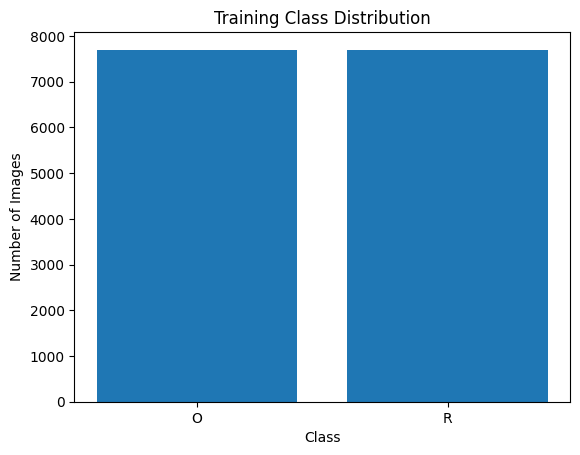

In [7]:
train_dist = class_distribution(train_dir)

plt.bar(train_dist.keys(), train_dist.values())
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

**Display Sample Images from Each Class**

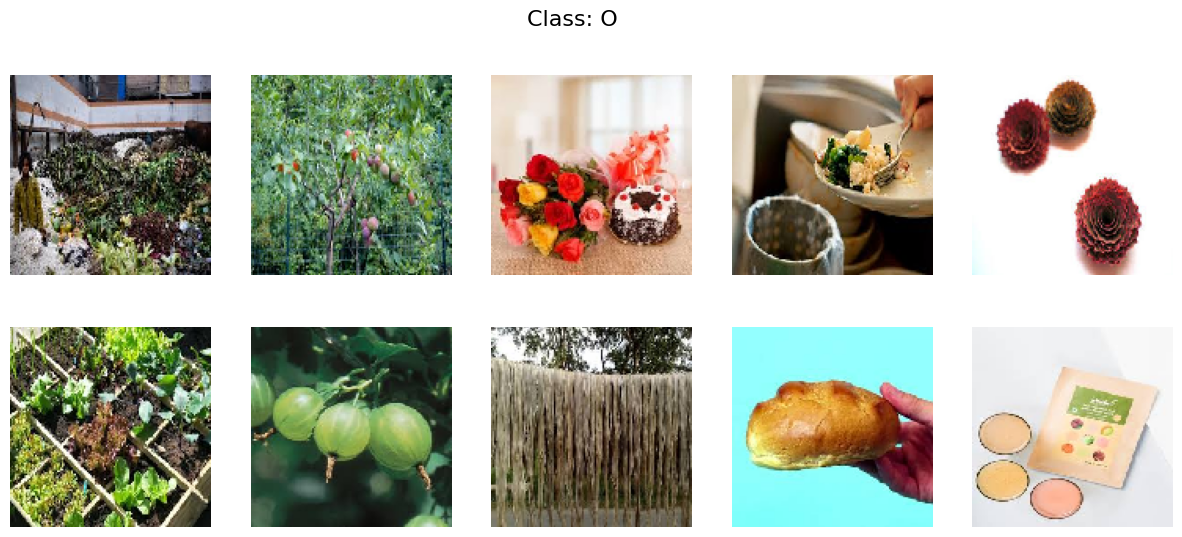

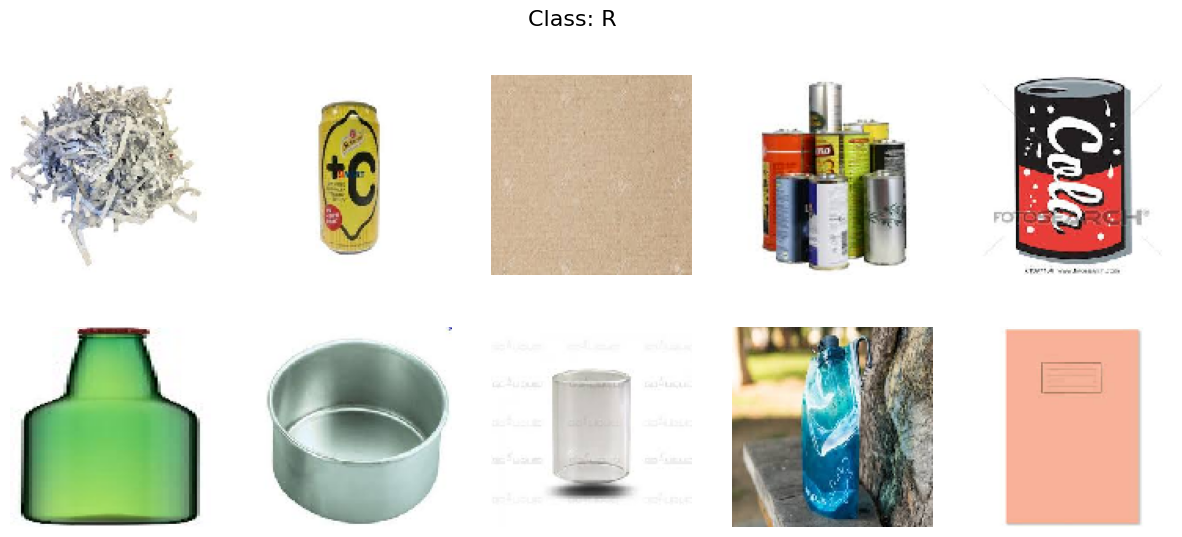

In [8]:
def show_10_images_each_class(folder):
    classes = os.listdir(folder)

    for class_name in classes:
        class_path = os.path.join(folder, class_name)
        image_files = os.listdir(class_path)

        # Randomly select 10 images
        sample_images = random.sample(image_files, 10)

        plt.figure(figsize=(15,6))
        plt.suptitle(f"Class: {class_name}", fontsize=16)

        for i, image_name in enumerate(sample_images):
            image_path = os.path.join(class_path, image_name)

            img = tf.keras.preprocessing.image.load_img(
                image_path, target_size=(128,128)
            )

            plt.subplot(2,5,i+1)   # 2 rows × 5 columns = 10 images
            plt.imshow(img)
            plt.axis("off")

        plt.show()

# Call function
show_10_images_each_class(train_dir)

**Image Preprocessing**

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255   # Normalize pixel values (0-255 → 0-1)
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),   # Resize images
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(train_generator.class_indices)

Found 15400 images belonging to 2 classes.
Found 3300 images belonging to 2 classes.
Found 3300 images belonging to 2 classes.
{'O': 0, 'R': 1}


**CNN Architecture**

In [14]:
# Build CNN Model
model = models.Sequential()

# Convolution Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        kernel_regularizer=l2(0.001),
                        input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((2,2)))

# Convolution Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu',
                        kernel_regularizer=l2(0.001)))
model.add(layers.MaxPooling2D((2,2)))

# Convolution Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu',
                        kernel_regularizer=l2(0.001)))
model.add(layers.MaxPooling2D((2,2)))

# Convolution Block 4
model.add(layers.Conv2D(128, (3,3), activation='relu',
                        kernel_regularizer=l2(0.001)))
model.add(layers.MaxPooling2D((2,2)))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=l2(0.001)))

# Dropout to prevent overfitting
model.add(layers.Dropout(0.5))

# Output Layer (Binary Classification)
model.add(layers.Dense(1, activation='sigmoid'))

# Show Model Summary
model.summary()

# Optimizer with custom learning rate
optimizer = Adam(learning_rate=0.0005)

# Compile Model
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 48s 175ms/step - accuracy: 0.7575 - loss: 0.7769 - val_accuracy: 0.8594 - val_loss: 0.4841
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 37s 152ms/step - accuracy: 0.8295 - loss: 0.5099 - val_accuracy: 0.8912 - val_loss: 0.3632
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 37s 155ms/step - accuracy: 0.8497 - loss: 0.4536 - val_accuracy: 0.8821 - val_loss: 0.3834
Epoch 4/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 38s 156ms/step - accuracy: 0.8492 - loss: 0.4400 - val_accuracy: 0.8958 - val_loss: 0.3421
Epoch 5/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 37s 151ms/step - accuracy: 0.8585 - loss: 0.4162 - val_accuracy: 0.9030 - val_loss: 0.3148
Epoch 6/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 42s 155ms/step - accuracy: 0.8710 - loss: 0.3930 - val_accuracy: 0.9070 - val_loss: 0.3012
Epoch 7/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.8708 - loss: 0.3879 - val_accuracy: 0.8591 - val_loss: 0.3671
Epoch 8/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 43s 177ms/step - accuracy: 0.8707 - loss: 0

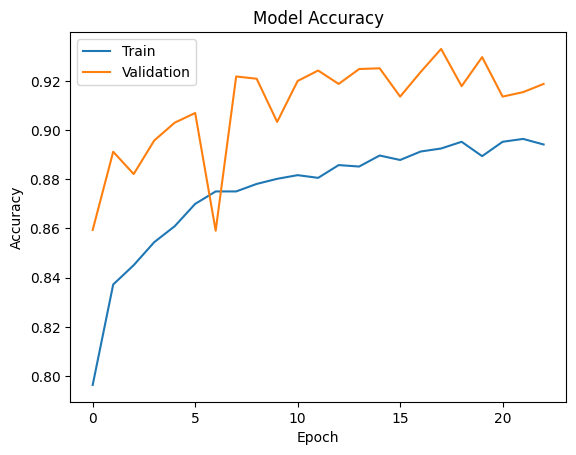

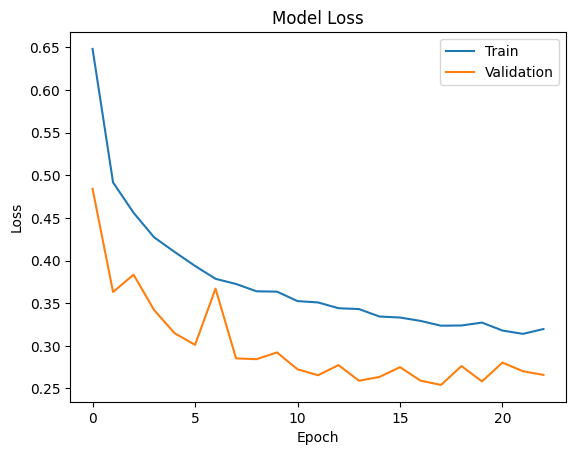

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


**Confusion Matrix**

52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step


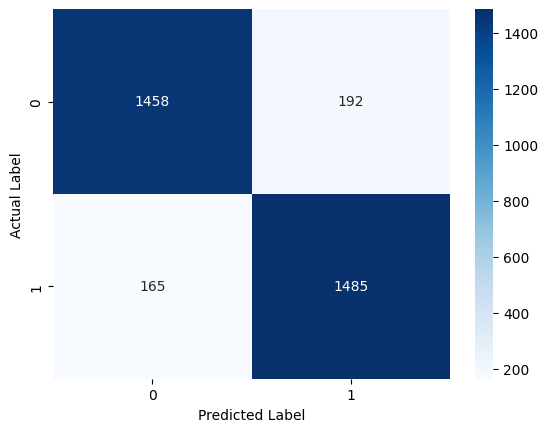

In [16]:
predictions = model.predict(test_generator)
y_pred = np.round(predictions)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Evaluation Matrix**

In [17]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8840 - loss: 0.3438
Test Accuracy: 0.8918181657791138


In [18]:


# Reset generator (important)
test_generator.reset()

# Get predictions
predictions = model.predict(test_generator)

# Convert probabilities to binary class (0 or 1)
y_pred = (predictions > 0.5).astype(int).flatten()

# True labels
y_true = test_generator.classes

# Precision
precision = precision_score(y_true, y_pred)

# Recall
recall = recall_score(y_true, y_pred)

# F1 Score
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step
Precision: 0.8855098389982111
Recall: 0.9
F1 Score: 0.8926961226330027

Classification Report:

              precision    recall  f1-score   support

           O       0.90      0.88      0.89      1650
           R       0.89      0.90      0.89      1650

    accuracy                           0.89      3300
   macro avg       0.89      0.89      0.89      3300
weighted avg       0.89      0.89      0.89      3300



**Show Sample Predictions**

/tmp/ipykernel_3913/3462274283.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = int(np.round(prediction[0]))


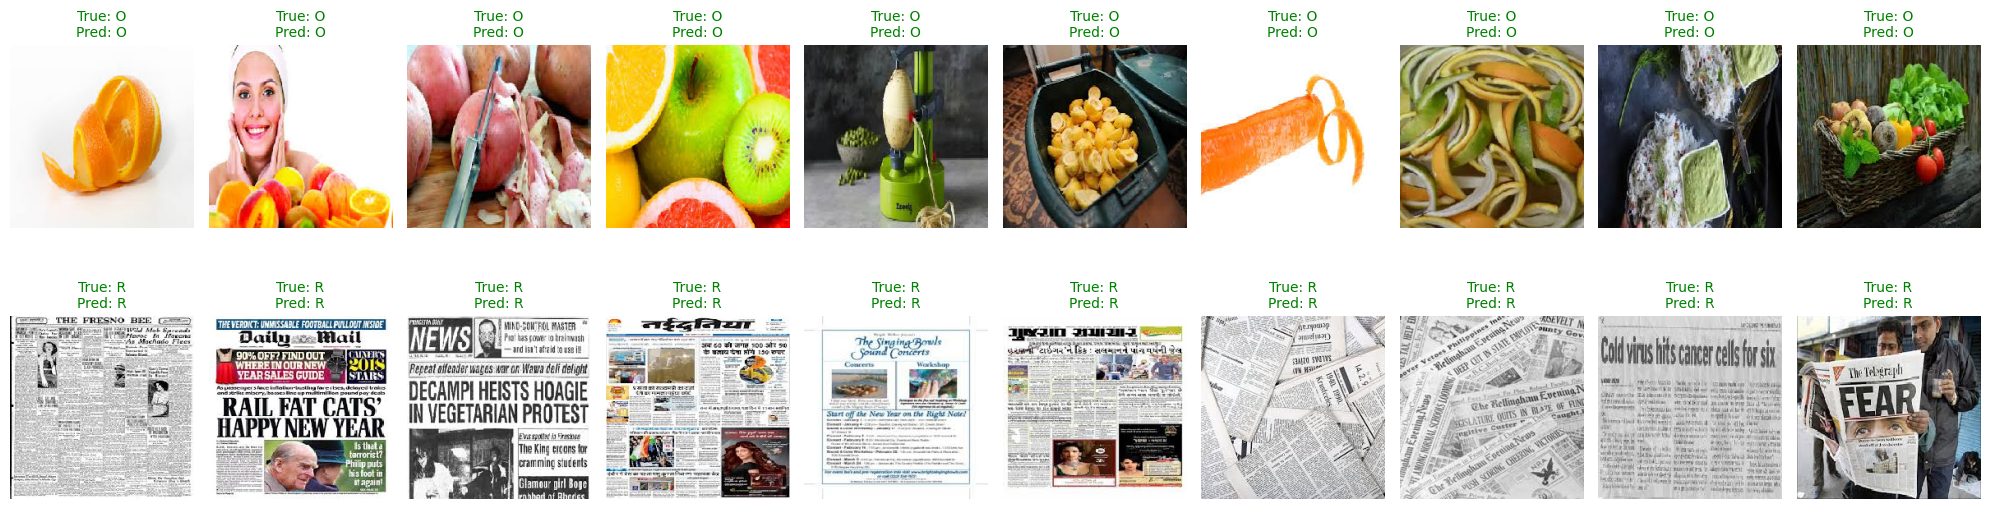

In [20]:
# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Store images per class
class_images = {0: [], 1: []}

# Create shuffled indices
indices = list(range(len(test_generator)))
random.shuffle(indices)

# Collect random images
for i in indices:

    imgs, labels = test_generator[i]

    for j in range(len(labels)):

        label = int(labels[j])

        if len(class_images[label]) < 10:
            class_images[label].append((imgs[j], label))

    if len(class_images[0]) == 10 and len(class_images[1]) == 10:
        break


plt.figure(figsize=(20,6))
plot_index = 1

for class_id in class_images:

    for img, true_label in class_images[class_id]:

        # Predict
        prediction = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_label = int(np.round(prediction[0]))

        # Green = correct, Red = wrong
        color = "green" if pred_label == true_label else "red"

        plt.subplot(2,10,plot_index)
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"True: {class_labels[true_label]}\nPred: {class_labels[pred_label]}",
            fontsize=10,
            color=color
        )

        plot_index += 1

plt.tight_layout()
plt.show()

In [22]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/model_v2.h5")

Mounted at /content/drive
